In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.problem_setup import TestProblemsSetup
from algorithms.cg_solvers import DynamicalLowRankPCG, DynamicalLowRankCG
from algorithms.rsvd_solvers import MatrixFreeRSVD
from utils.metrics import error3
from utils.utils import progress_bar, disk_cache
from utils.exact_forward_operator import ExactForwardOperatorFast, fast_get_weights, solve_explicit

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15
SETUP = TestProblemsSetup(n=64)
PROBLEMS = SETUP.get_test_problems()
PROBLEM_PARAMS = SETUP.problem_params
RESULTS_FOLDER = '../../results/low_rank_error'

def plot_multiple_f(
        x_list, pid,
        names=None, fig_name=None, shrink=0,
        layout=None, figsize=None, labelpad=10
    ):
    from utils.colors import CMAP
    from utils.plotting import save_plot
    import matplotlib.patches as patches

    pb = PROBLEMS[pid]
    PBP = PROBLEM_PARAMS[pid]
    width, height = PBP['width'], PBP['height']
    x0s, y0s = PBP['x0'], PBP['y0']

    f_list = []
    for x in x_list:
        f = Function(pb['V_h'])
        f.vector()[:] = x
        f_list.append(f)

    if figsize is None: figsize = (6, 6)
    if names is None: names = ['' for _ in f_list]
    if layout is None: layout = (2, 2)

    fig, axes = plt.subplots(*layout, figsize=figsize)
    
    for ax, func, name in zip(axes.flat, f_list, names):
        plt.sca(ax)
        p = plot(func, cmap=CMAP)
        if shrink != 0: fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(name, labelpad=labelpad)

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)
    
    plt.tight_layout()
    save_plot(fig_name=fig_name)
    plt.show()


/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
@disk_cache(RESULTS_FOLDER)
def experiment(k_range, pid, repeat):
    results = []

    n_steps, step = len(k_range) * repeat, 1
    for k in k_range:
        pb = PROBLEMS[pid]
        rsvd = MatrixFreeRSVD(pb['V_h'])

        for r in range(repeat):
            progress_bar(step, n_steps, end_text=f' [{k=}]'); step += 1
            result = {'k': k}

            rsvd.solve(k=k, seed=SEED + k + r)
            w = rsvd.weights()

            # full-rank rSVD solution
            x_hat = rsvd.tikhonov_solve(pb['y'], w, lam=1e-4)
            error = {k + '_rsvd': v for k, v in error3(pb['x'], x_hat).items()}
            result.update(error)

            # Rank-1 solution
            solver = DynamicalLowRankCG(rsvd, pb['x'])
            x_hat = solver.solve(pb['y'], w, lambda_=1e-4, max_rank=1,
                                 rtol=1e-10, max_iter=500, seed=SEED + r, verbose=False)
            error = {k + '_dlra1': v for k, v in error3(pb['x'], x_hat).items()}
            result.update(error)

            # Rank-2 solution
            x_hat = solver.solve(pb['y'], w, lambda_=1e-4, max_rank=2,
                                 rtol=1e-10, max_iter=500, seed=SEED + r, verbose=False)
            error = {k + '_dlra2': v for k, v in error3(pb['x'], x_hat).items()}
            result.update(error)

            # Rank-5 solution
            x_hat = solver.solve(pb['y'], w, lambda_=1e-4, max_rank=5,
                                 rtol=1e-10, max_iter=500, seed=SEED + r, verbose=False)
            error = {k + '_dlra5': v for k, v in error3(pb['x'], x_hat).items()}
            result.update(error)
            
            results.append(result)
    
    return pd.DataFrame(results)


@disk_cache(RESULTS_FOLDER)
def experiment2(pid: str):
    """
    Experiment: measure the weighted Tikhonov solution error.
    """
    pb = PROBLEMS[pid]

    exact = ExactForwardOperatorFast(pb['V_h'])
    f_hat = solve_explicit(
        operator=exact,
        w=exact.get_weights(),
        y=pb['y'],
        lambda_=1e-4
    )
    x_hat = f_hat.vector().get_local()

    results = error3(pb['x'], x_hat)
    return pd.DataFrame([results])

k_range = np.arange(5, 105)
df = experiment(k_range, pid='I', repeat=30)
df_exact = experiment2(pid='I')
df_stats = df.groupby('k').agg(['mean', 'std'])

../../figures/low_rank_solution_error_I.png already exists


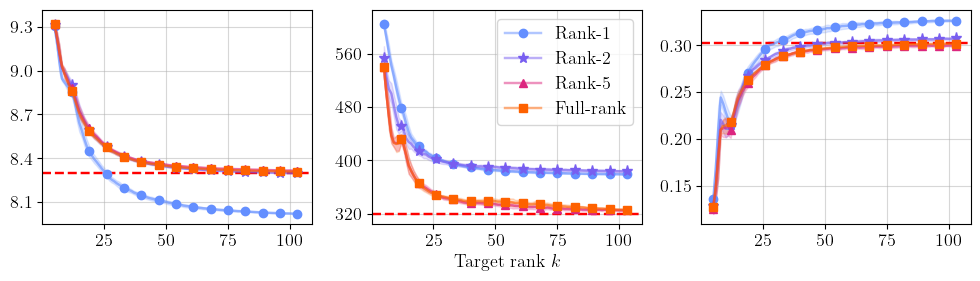

In [3]:
def plot_df_stats(df, df_exact, fig_name=None):
    from utils.colors import C5, M, MS
    import matplotlib.ticker as ticker
    from matplotlib.lines import Line2D
    from utils.plotting import save_plot

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    metrics = ['euclidean', 'emd', 'auc_iou']
    methods = ['_dlra1', '_dlra2', '_dlra5', '_rsvd']
    labels = ['Rank-1', 'Rank-2', 'Rank-5', 'Full-rank']
    s = 7

    for ax, metric in zip(axes.flat, metrics):
        ax.axhline(df_exact[metric].values[0], ls='--', color='r', lw=1.75)
        
        for i, method in enumerate(methods):
            dfi = df[metric + method]
            mean, std = dfi['mean'], dfi['std']

            ax.plot(dfi.index, mean, alpha=.65, lw=1.75, c=C5[i])
            ax.plot(dfi.index[::s], mean[::s], M[i], c=C5[i], ms=MS[i])   

            ax.fill_between(
                dfi.index, mean - std, mean + std,
                color=C5[i],alpha=0.2
            ) 

        ax.xaxis.set_major_locator(ticker.MaxNLocator(5)) 
        ax.yaxis.set_major_locator(ticker.MaxNLocator(5)) 
        ax.grid(True, alpha=.5)

    # Custom legend
    handles = []
    for i in range(4):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=1.75, alpha=0.5)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))


    #ax.set_xlim(5, 55)
    axes[1].set_xlabel('Target rank $k$')
    axes[1].legend(handles=handles, labels=labels)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.22)

    save_plot(fig_name)
    plt.show()


plot_df_stats(df_stats, df_exact, fig_name='low_rank_solution_error_I')

In [4]:
k_range = np.arange(5, 105)
df2 = experiment(k_range, pid='II', repeat=15)
df2_exact = experiment2(pid='II')
df2_stats = df2.groupby('k').agg(['mean', 'std'])

../../figures/low_rank_solution_error_II.png already exists


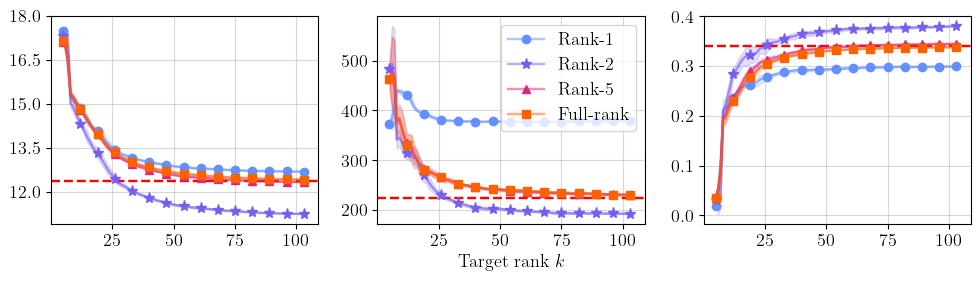

In [5]:
plot_df_stats(df2_stats, df2_exact, fig_name='low_rank_solution_error_II')

In [41]:
def print_summary(df_stats, df_exact, rank):
    metric = 'euclidean'
    for metric in ['euclidean', 'emd', 'auc_iou']:
        subset = df_stats[f'{metric}_dlra{rank}']['mean']

        if metric != 'auc_iou':
            mask = subset <= df_exact[metric].values[0]
        else:
            mask = subset >= df_exact[metric].values[0]
        
        if len(subset[mask]) == 0:
            print(f"{metric}: doesn't surpasses exact full-rank")
        else:
            idx = subset[mask].index[0]
            print(f"{metric}: surpasses exact full-rank at rank {idx}")

print("Problem I")
print_summary(df_stats, df_exact, rank=1)

print("Problem II")
print_summary(df2_stats, df2_exact, rank=2)

Problem I
euclidean: surpasses exact full-rank at rank 26
emd: doesn't surpasses exact full-rank
auc_iou: surpasses exact full-rank at rank 31
Problem II
euclidean: surpasses exact full-rank at rank 28
emd: surpasses exact full-rank at rank 28
auc_iou: surpasses exact full-rank at rank 26
